🛫 Airline Passenger Satisfaction – Project Explanation
1. Problem Statement

The goal of this project is to predict whether a passenger is satisfied or dissatisfied with an airline service based on their flight experience.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Dataset

The dataset contains about 1,29,898 passenger records.

Each record includes details like:

Personal info → Age, Gender, Customer Type (loyal/disloyal).

Flight info → Travel type (business/personal), Class (Eco/Business), Flight Distance, Delays.

Service ratings → WiFi, Seat comfort, Food & drink, Entertainment, Cleanliness, etc. (rated 1–5).

Target column → Satisfaction (Satisfied or Neutral/Dissatisfied).

In [ ]:
df=pd.read_csv('flightdataset.csv')
df.sample(5)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
50917,50917,105605,Female,disloyal Customer,30,Business travel,Business,883,1,1,...,1,5,5,5,4,5,1,15,0.0,neutral or dissatisfied
51960,51960,64806,Female,Loyal Customer,39,Business travel,Business,2390,2,2,...,5,5,5,4,3,5,4,0,0.0,satisfied
119494,15590,39257,Male,disloyal Customer,57,Business travel,Eco,67,3,3,...,1,2,3,2,2,2,1,48,36.0,neutral or dissatisfied
97592,97592,67497,Male,Loyal Customer,59,Personal Travel,Eco Plus,769,3,5,...,2,5,2,5,4,4,2,12,2.0,neutral or dissatisfied
23329,23329,100208,Male,Loyal Customer,29,Business travel,Business,3024,1,1,...,5,5,3,4,3,4,5,0,0.0,satisfied


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129879 entries, 0 to 129878
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         129879 non-null  int64  
 1   id                                 129879 non-null  int64  
 2   Gender                             129879 non-null  object 
 3   Customer Type                      129879 non-null  object 
 4   Age                                129879 non-null  int64  
 5   Type of Travel                     129879 non-null  object 
 6   Class                              129879 non-null  object 
 7   Flight Distance                    129879 non-null  int64  
 8   Inflight wifi service              129879 non-null  int64  
 9   Departure/Arrival time convenient  129879 non-null  int64  
 10  Ease of Online booking             129879 non-null  int64  
 11  Gate location                      1298

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


In [ ]:
df.shape


(129879, 25)

3. Data Preprocessing

Handled missing values → replaced with median (numbers) or mode (categories).

Encoded categorical features (Gender, Customer Type, Travel Type, Class) into numbers so ML can use them.

Target variable was converted:

Satisfied = 1

Neutral/Dissatisfied = 0.

In [ ]:
num_col=[]
cate_col=[]
for i in df.columns:
  if(df[i].dtype=='float' or df[i].dtype=='int'):
    num_col.append(i)
else:
  cate_col.append(i)


In [ ]:
for col in num_col:
    df[col].fillna(df[col].median(), inplace=True)
for col in cate_col:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-2464699413.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-2464699413.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000,129879.000000
mean,44161.240023,64940.849437,39.427860,1190.324325,2.728678,3.057592,2.756874,2.976917,3.204775,3.252627,3.441365,3.358064,3.383010,3.350865,3.632104,3.306277,3.642182,3.286313,14.713441,15.045242
std,31208.055732,37493.203664,15.119378,997.452220,1.329330,1.526745,1.401745,1.278521,1.329938,1.350722,1.319293,1.334046,1.287096,1.316249,1.180023,1.266185,1.176668,1.313679,38.071147,38.416417
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16236.000000,32471.500000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,38967.000000,64941.000000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,71436.500000,97410.500000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103906.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


4. Exploratory Data Analysis (EDA)

EDA helps us understand the data before modeling.

Class Distribution

Most passengers are from Economy class

Business class passengers report higher satisfaction.

Gender

Both Male and Female passengers present

Gender has less effect on satisfaction compared to service quality.

Customer Type

Loyal Customers are more likely to be satisfied.

Disloyal Customers give lower ratings.

Type of Travel

Business Travel → more satisfaction.

Personal Travel → more dissatisfaction.

Service Ratings

Higher scores in seat comfort, entertainment, and boarding → higher satisfaction.

Poor WiFi and food ratings often lead to dissatisfaction.

Delays

Longer delays = lower satisfaction.

Passengers with 0 delays report more satisfaction.

📊 Visuals Used in EDA:

Countplots → Gender, Class, Travel Type vs Satisfaction

Boxplots → Delays vs Satisfaction

Correlation Heatmap → Relationship between service features and satisfaction

Bar charts → Average ratings for satisfied vs dissatisfied passengers

In [ ]:
df['satisfaction'].value_counts()

,count
satisfaction,
neutral or dissatisfied,73452
satisfied,56427


<Axes: xlabel='satisfaction', ylabel='count'>

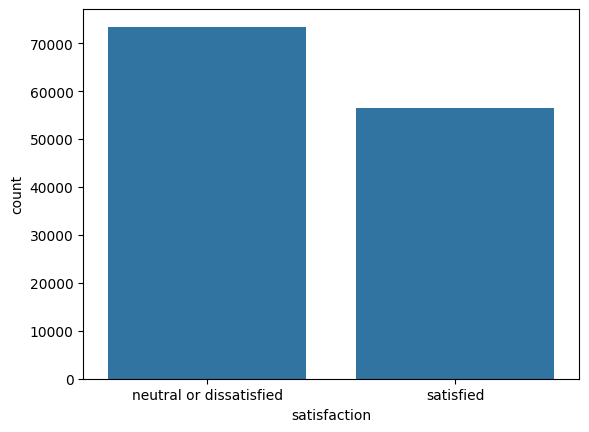

In [ ]:
sns.countplot(x='satisfaction',data=df)

<Axes: xlabel='Class', ylabel='count'>

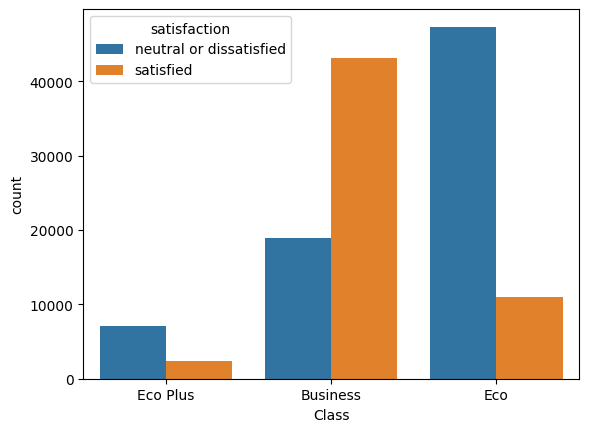

In [ ]:
sns.countplot(x='Class', hue='satisfaction', data=df)

In [ ]:
df['Customer Type'].value_counts()

,count
Customer Type,
Loyal Customer,106099
disloyal Customer,23780


<Axes: xlabel='Customer Type', ylabel='count'>

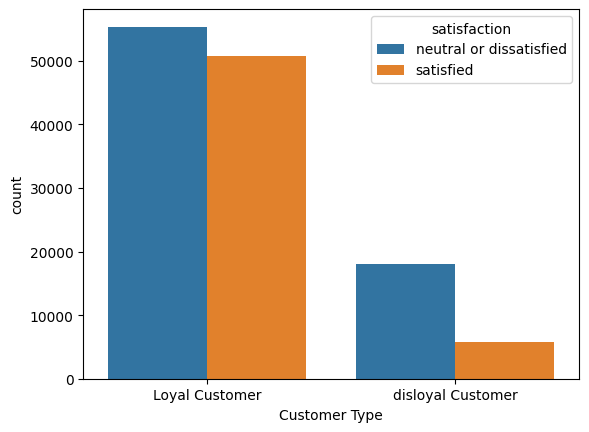

In [ ]:
sns.countplot(data=df, x='Customer Type', hue='satisfaction')

<Axes: xlabel='Customer Type', ylabel='count'>

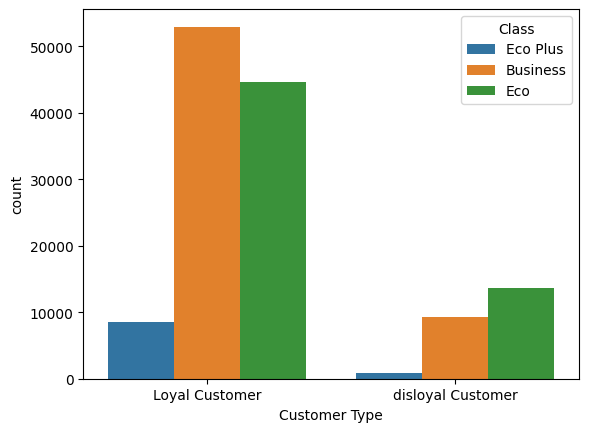

In [ ]:
sns.countplot(data=df, x='Customer Type', hue='Class')

<Axes: xlabel='Gender', ylabel='count'>

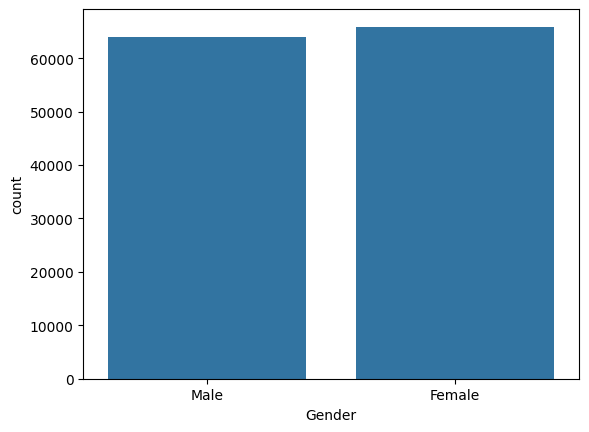

In [ ]:
sns.countplot(data=df,x="Gender")

<Axes: xlabel='Gender', ylabel='count'>

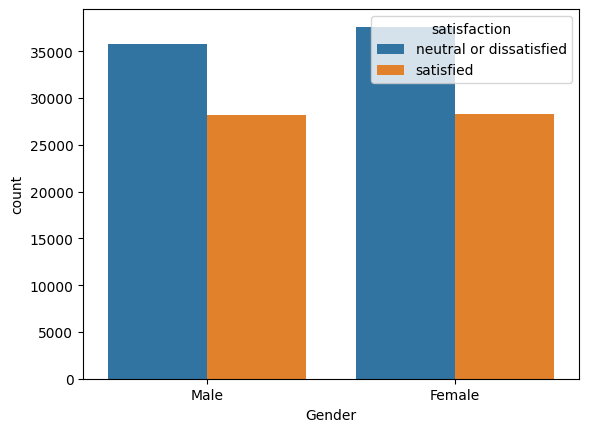

In [ ]:
sns.countplot(data=df,x="Gender",hue="satisfaction")

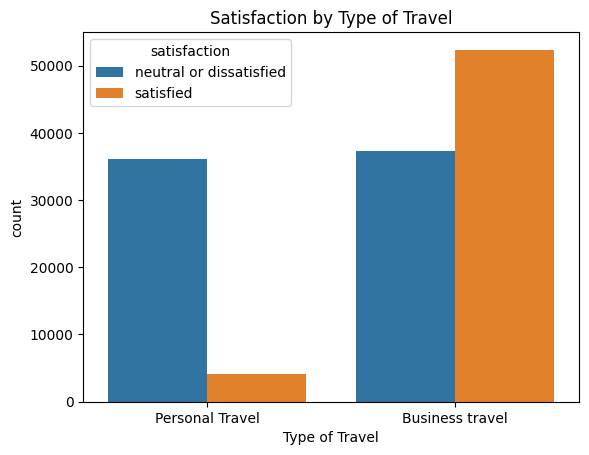

In [ ]:
sns.countplot(x='Type of Travel', hue='satisfaction', data=df)
plt.title('Satisfaction by Type of Travel')
plt.show()


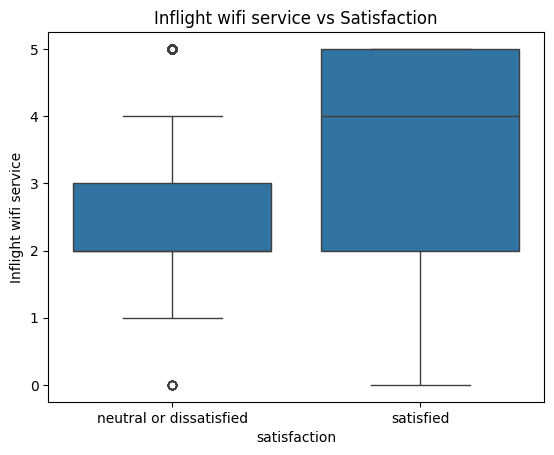

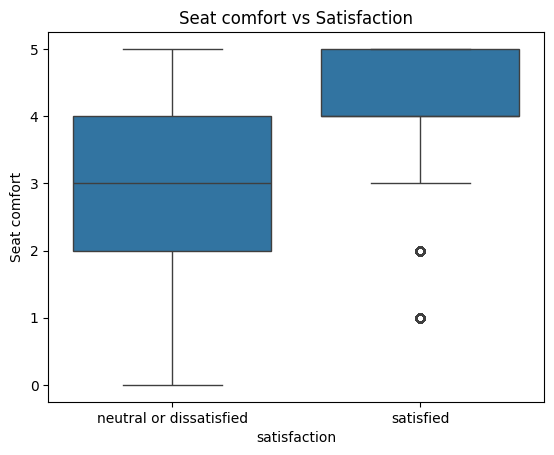

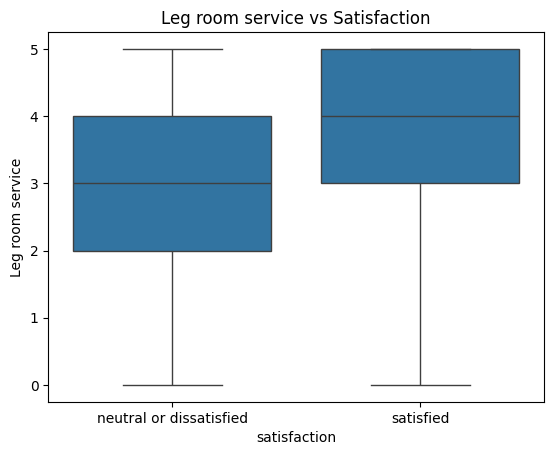

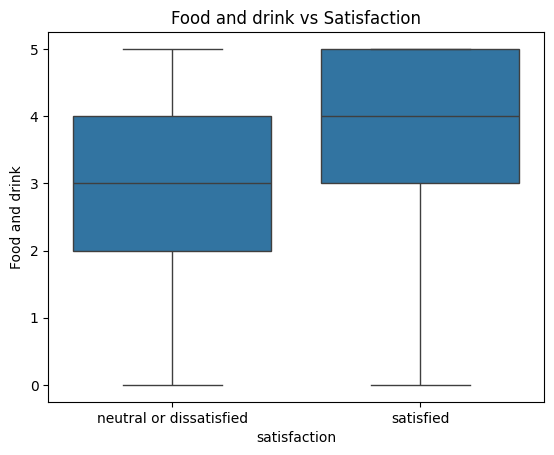

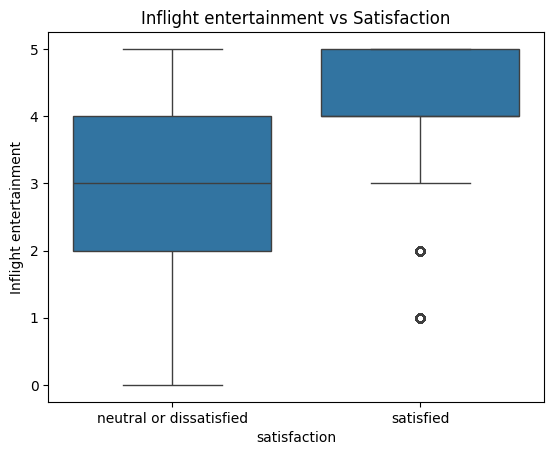

In [ ]:
service_cols = ['Inflight wifi service', 'Seat comfort', 'Leg room service', 'Food and drink', 'Inflight entertainment']

for col in service_cols:
    sns.boxplot(x='satisfaction', y=col, data=df)
    plt.title(f'{col} vs Satisfaction')
    plt.show()


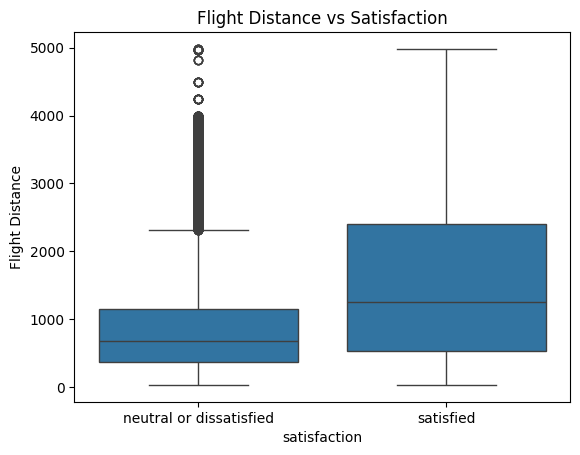

In [ ]:
sns.boxplot(x='satisfaction', y='Flight Distance', data=df)
plt.title('Flight Distance vs Satisfaction')
plt.show()


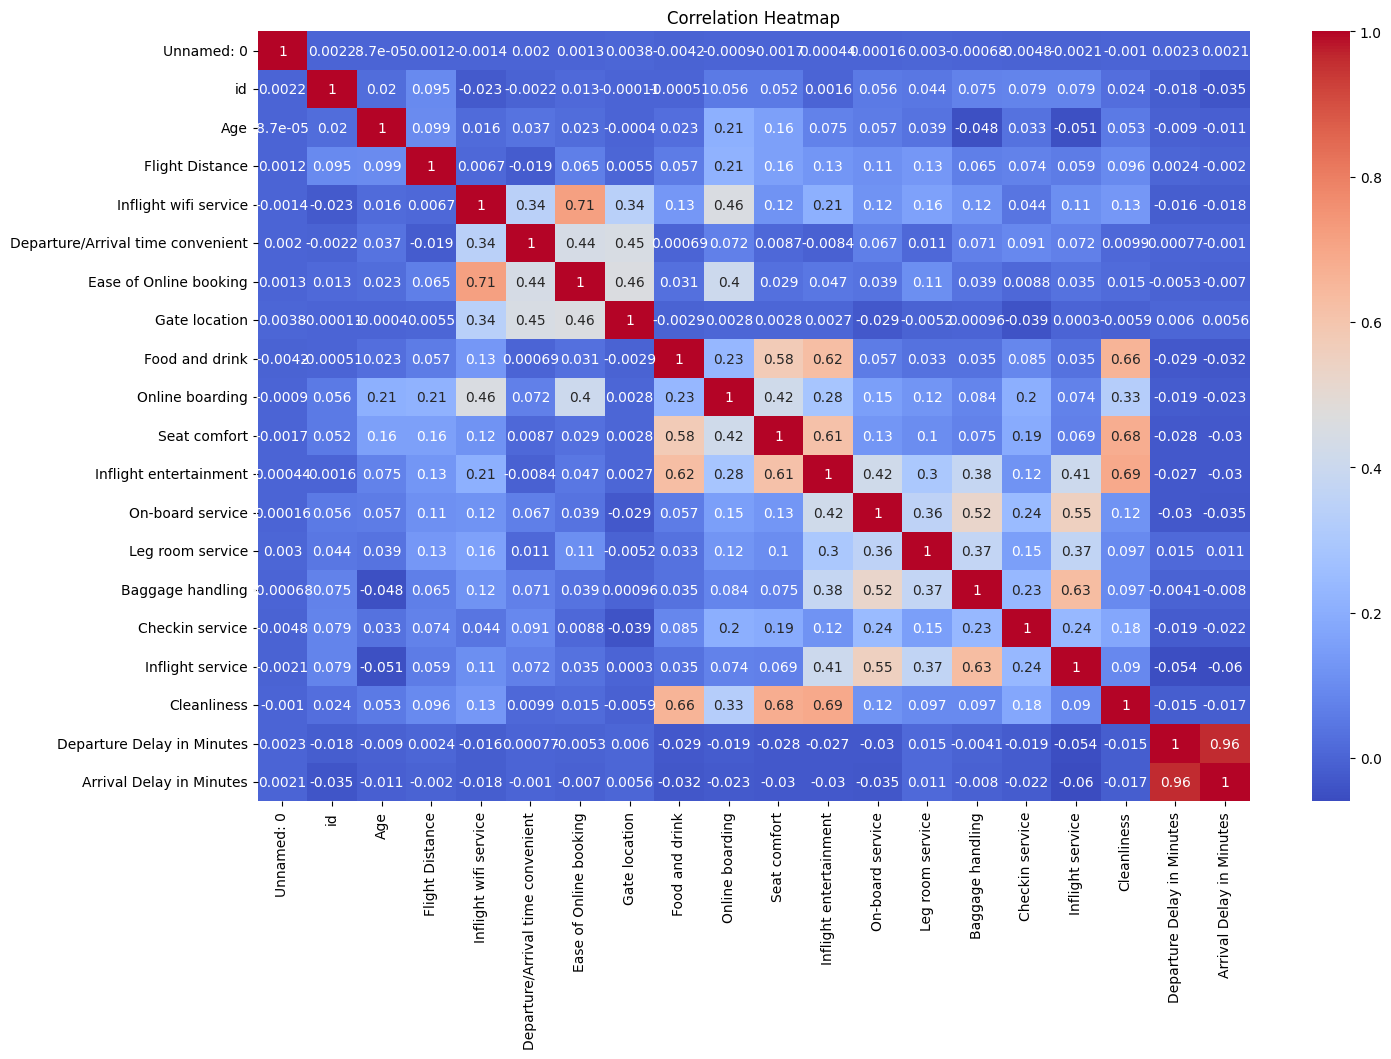

In [ ]:

plt.figure(figsize=(16,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

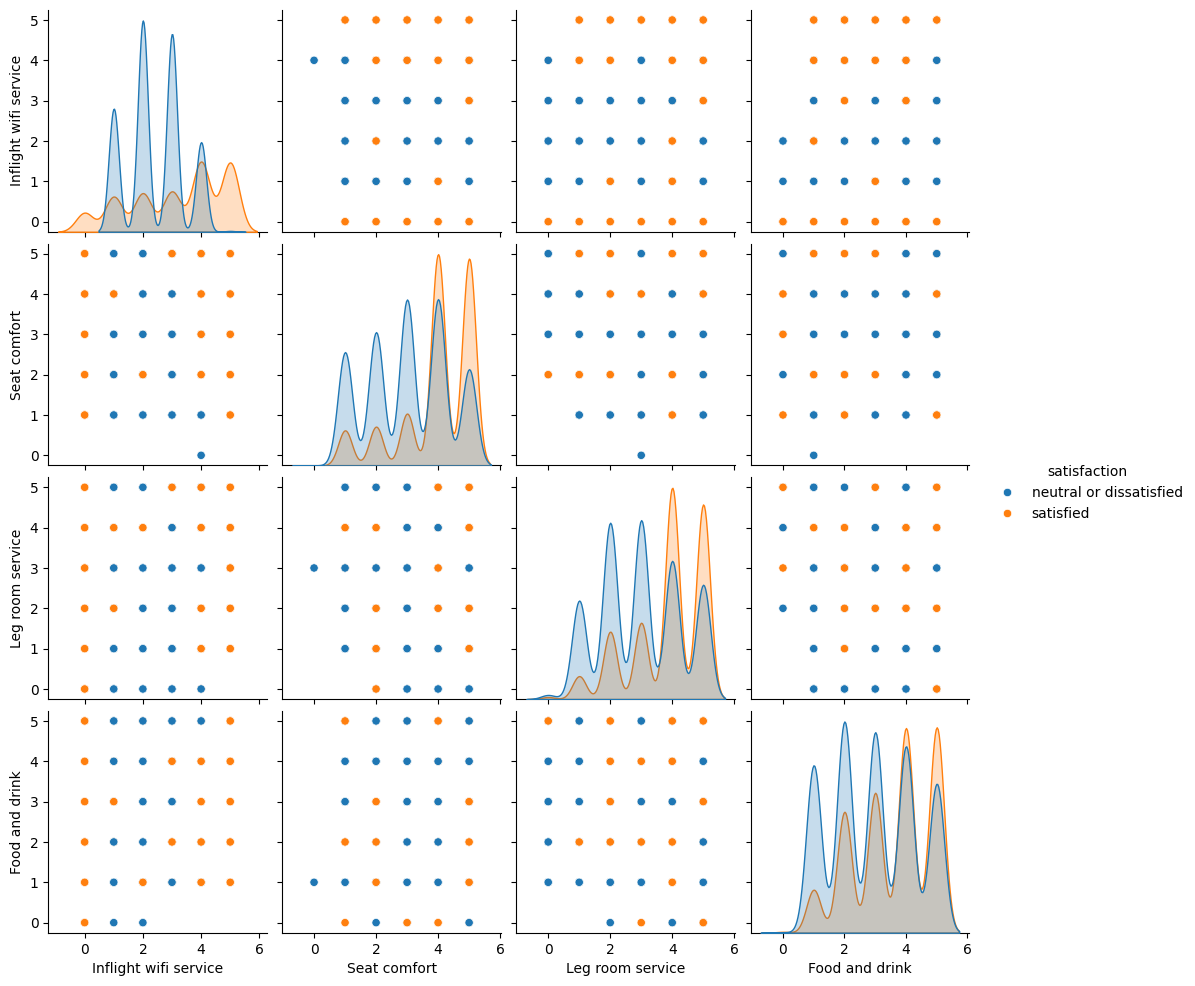

In [ ]:
selected_cols = ['Inflight wifi service', 'Seat comfort', 'Leg room service', 'Food and drink', 'satisfaction']
sns.pairplot(df[selected_cols], hue='satisfaction')
plt.show()



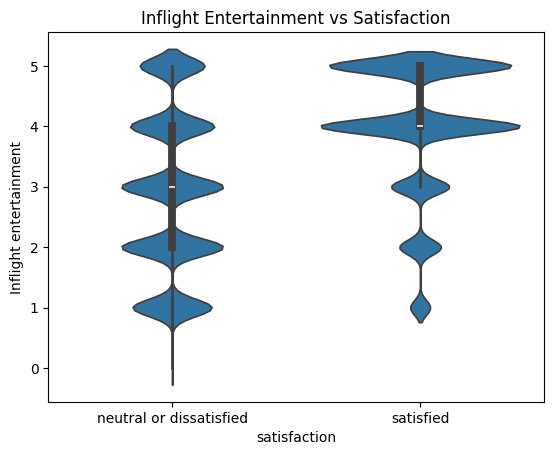

In [ ]:
sns.violinplot(x='satisfaction', y='Inflight entertainment', data=df)
plt.title('Inflight Entertainment vs Satisfaction')
plt.show()


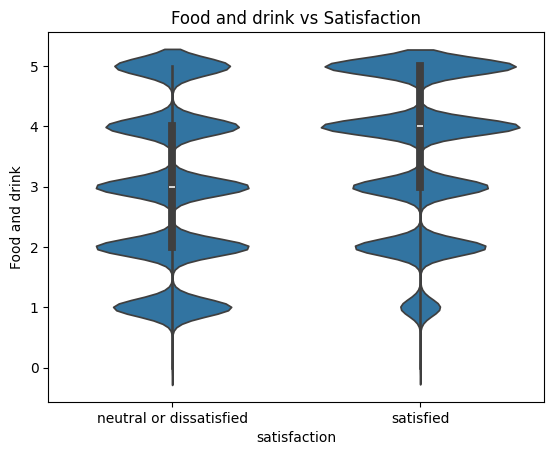

In [ ]:
sns.violinplot(x='satisfaction', y='Food and drink', data=df)
plt.title('Food and drink vs Satisfaction')
plt.show()


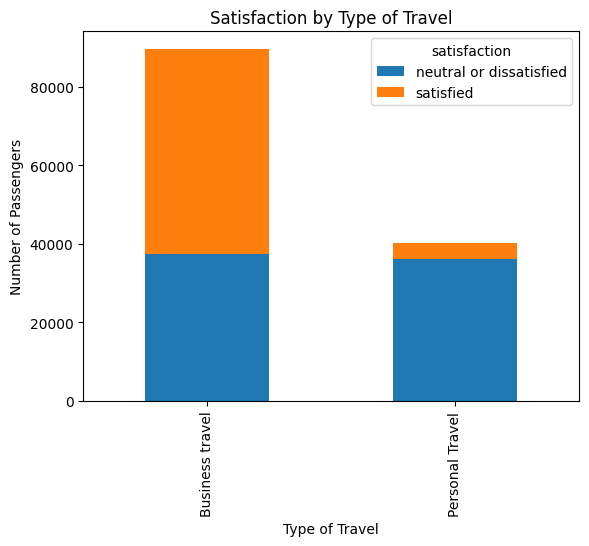

In [ ]:
pd.crosstab(df['Type of Travel'], df['satisfaction']).plot(kind='bar', stacked=True)
plt.title('Satisfaction by Type of Travel')
plt.ylabel('Number of Passengers')
plt.show()


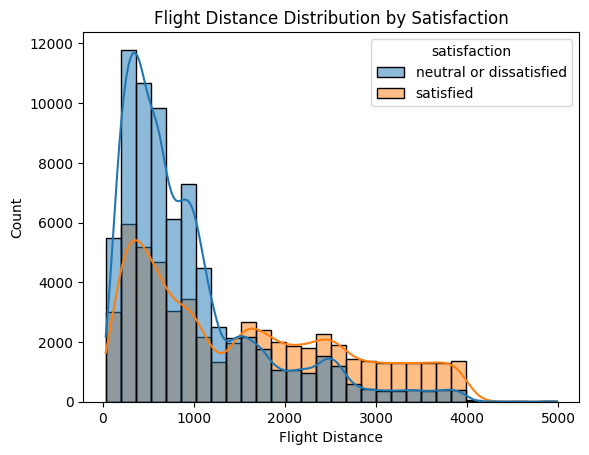

In [ ]:
sns.histplot(data=df, x='Flight Distance', hue='satisfaction', kde=True, bins=30)
plt.title('Flight Distance Distribution by Satisfaction')
plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Customer Type'] = le.fit_transform(df['Customer Type'])
df['Gender'] = le.fit_transform(df['Gender'])
df['Class'] = le.fit_transform(df['Class'])
df['Type of Travel'] = le.fit_transform(df['Type of Travel'])
df['satisfaction'] = le.fit_transform(df['satisfaction'])



5. Models Used

Random Forest (baseline, interpretable)

XGBoost (boosting, higher accuracy)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X=df.drop(columns=['satisfaction','Unnamed: 0','id', 'Gender'])
y=df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

/tmp/ipython-input-2179988801.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')


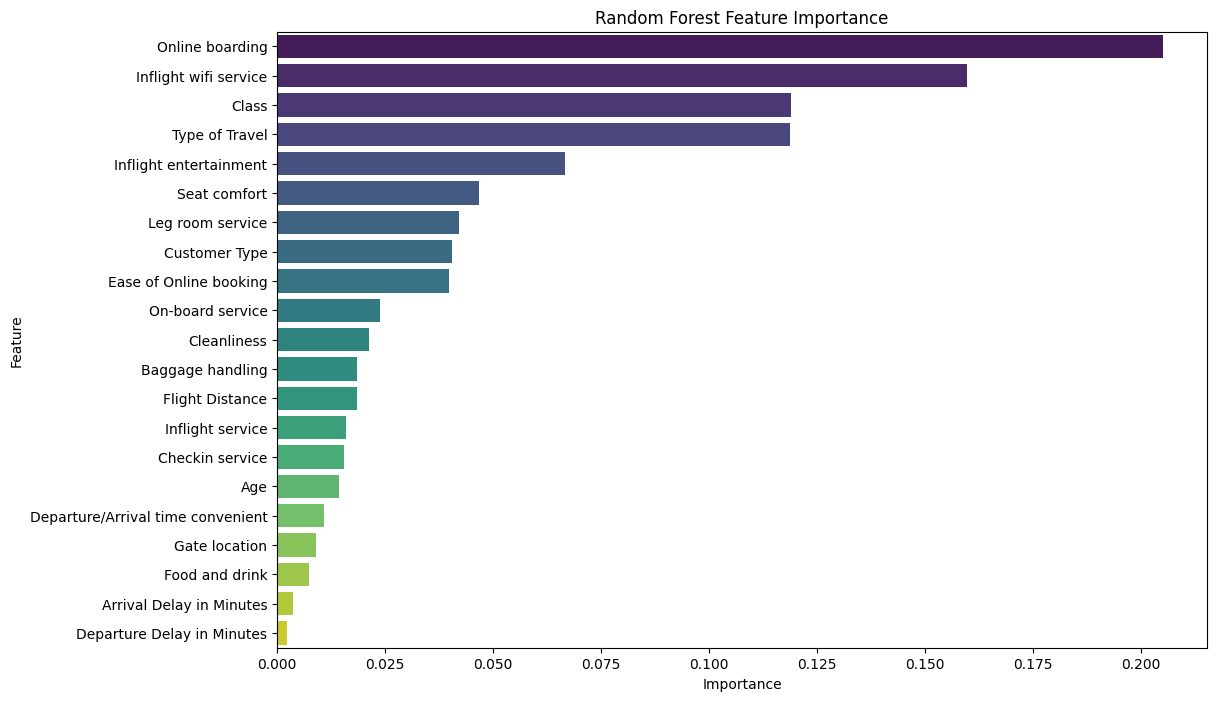

In [ ]:
# Get feature importances
importances = rf.feature_importances_
features = X.columns

# Create a DataFrame for easy sorting
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)  # Sort ascending for horizontal bar plot

# Plot
plt.figure(figsize=(12,8))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


y_pred = rf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9479519556513705


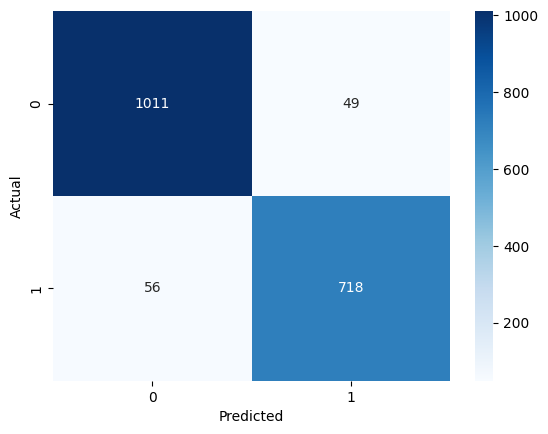

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1060
           1       0.94      0.93      0.93       774

    accuracy                           0.94      1834
   macro avg       0.94      0.94      0.94      1834
weighted avg       0.94      0.94      0.94      1834



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:15:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9541984732824428
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1060
           1       0.95      0.94      0.95       774

    accuracy                           0.95      1834
   macro avg       0.95      0.95      0.95      1834
weighted avg       0.95      0.95      0.95      1834



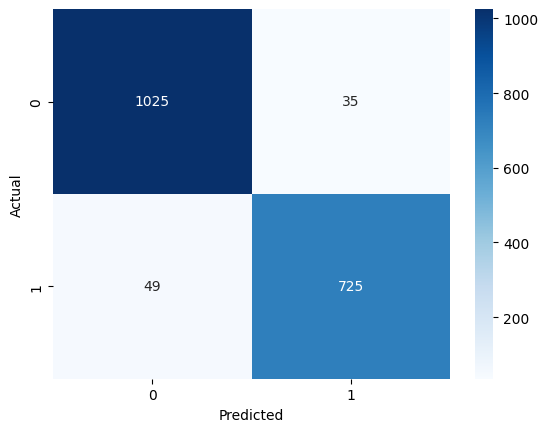

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize model
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')

# Train model
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:", acc)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


/tmp/ipython-input-3011937634.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_xgb, palette='viridis')


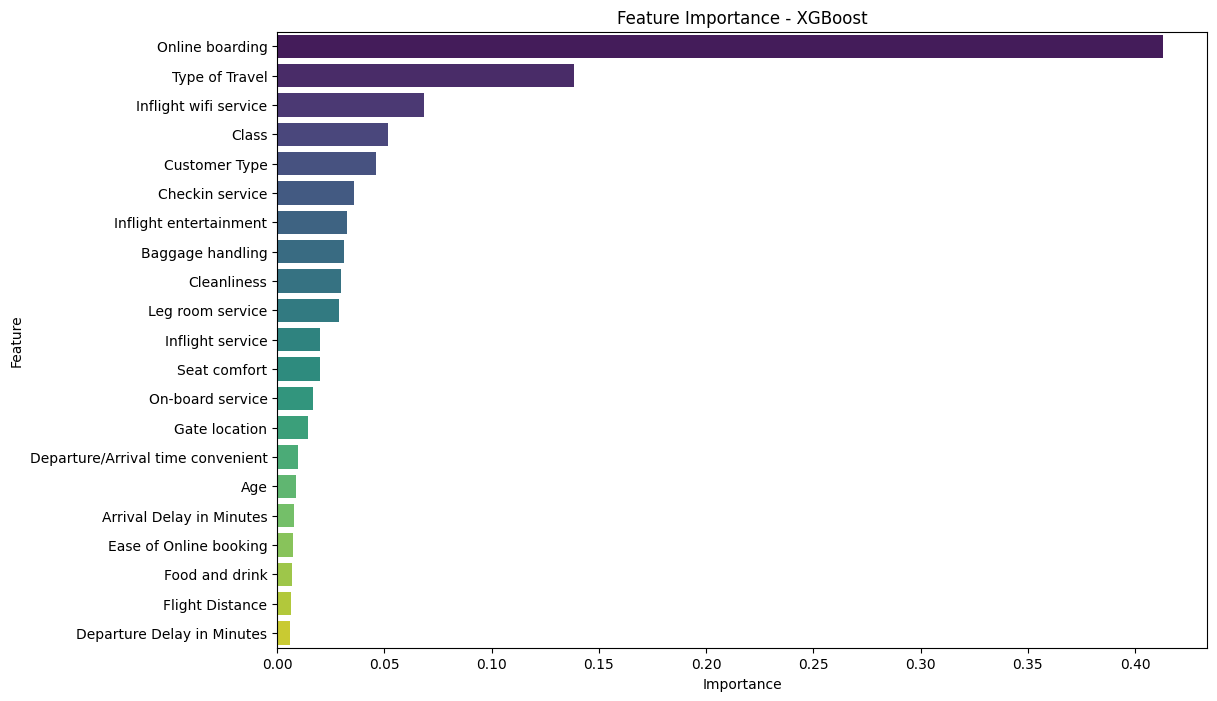

In [ ]:
importances = xgb_model.feature_importances_
features = X.columns

# Create a DataFrame for easy sorting
feat_imp_xgb = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_xgb = feat_imp_xgb.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12,8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_xgb, palette='viridis')
plt.title('Feature Importance - XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [ ]:
X_7=df[["Online boarding","Inflight wifi service","Class","Type of Travel","Inflight entertainment","Seat comfort","Leg room service"]]
X_train, X_test, y_train, y_test = train_test_split(X_7, y, test_size=0.2, random_state=42)
rf_7 = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

rf_7.fit(X_train, y_train)
y_pred = rf_7.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


Accuracy: 0.931706190329535


In [ ]:
X_test


,Online boarding,Inflight wifi service,Class,Type of Travel,Inflight entertainment,Seat comfort,Leg room service
1501,4.0,1.0,1,0,4.0,4.0,4.0
4708,5.0,4.0,1,0,4.0,1.0,4.0
6008,4.0,1.0,2,1,2.0,5.0,1.0
4347,3.0,3.0,2,1,4.0,4.0,4.0
2420,3.0,3.0,2,1,4.0,4.0,5.0
...,...,...,...,...,...,...,...
58,3.0,3.0,1,0,4.0,4.0,1.0
4394,2.0,2.0,2,0,2.0,2.0,1.0
1155,3.0,2.0,2,0,2.0,3.0,2.0
2499,2.0,2.0,2,1,2.0,2.0,2.0


In [ ]:

y_pred = rf.predict(X_test)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- Age
- Arrival Delay in Minutes
- Baggage handling
- Checkin service
- Cleanliness
- ...


7. Conclusion

ML can predict airline satisfaction with good accuracy.

Improving service areas (boarding, comfort, WiFi) boosts satisfaction.

Airlines can use insights to enhance passenger experience.